In [2]:
# Install required packages
#%pip install -qq netcdf4 xarray harmony-py python-cmr geopandas wget
%pip install -qq pandas xarray matplotlib netcdf4 pyproj pyrsig pycno thefuzz
%pip install git+https://github.com/barronh/pyrsig.git

Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/barronh/pyrsig.git to /tmp/pip-req-build-5h632u72
  Running command git clone --filter=blob:none --quiet https://github.com/barronh/pyrsig.git /tmp/pip-req-build-5h632u72
  Resolved https://github.com/barronh/pyrsig.git to commit a748195bc38f4566893634a5e010308f4ca8b97f
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Load packages into current runtime
import datetime as dt
import geopandas as gpd

import subprocess
import cmr
import wget
import os

# Import Libraries
import pyrsig
import pandas as pd
import pycno
import getpass
import matplotlib.pyplot as plt
from collections import defaultdict
import re
from thefuzz import process, fuzz

In [4]:
# Get United States urban areas shapefile
# This is written to be used on a linux machine, might not work on mac
if(not os.path.isdir("city_shapefile")):
    os.makedirs("city_shapefile")
    wget.download("https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_ua10_500k.zip", out="./city_shapefile")
    !unzip city_shapefile/* -d ./city_shapefile
    !rm city_shapefile/*.zip

gdf_cities = gpd.read_file("city_shapefile/")

#  Verify the cities were loaded correctly
city_names = gdf_cities['NAME10']
print(city_names)

0                      Tucson, AZ
1                     Alturas, CA
2               Davenport, IA--IL
3              Waynesboro, PA--MD
4                      Angola, IN
                  ...            
3596                   Milton, DE
3597          Sugarmill Woods, FL
3598    Lake Conroe Eastshore, TX
3599                 Checotah, OK
3600        De Funiak Springs, FL
Name: NAME10, Length: 3601, dtype: object


In [5]:
# Populates a dictionary that converts a states two-letter post code into a fips code
postal_to_fips = dict()
with open("fips.txt", "r") as file:
    for line in file:
        # Uses list comprehension to only get the entries that are 2 uppercase letters
        line = [s for s in re.split("\t| ", line[:-1]) if len(s) == 2 and s.upper() == s]
        postal_to_fips[line[0]] = line[1]

print(postal_to_fips)

{'AL': '01', 'NE': '31', 'AK': '02', 'NV': '32', 'AZ': '04', 'NH': '33', 'AR': '05', 'NJ': '34', 'CA': '06', 'NM': '35', 'CO': '08', 'NY': '36', 'CT': '09', 'NC': '37', 'DE': '10', 'ND': '38', 'DC': '11', 'OH': '39', 'FL': '12', 'OK': '40', 'GA': '13', 'OR': '41', 'HI': '15', 'PA': '42', 'ID': '16', 'PR': '72', 'IL': '17', 'RI': '44', 'IN': '18', 'SC': '45', 'IA': '19', 'SD': '46', 'KS': '20', 'TN': '47', 'KY': '21', 'TX': '48', 'LA': '22', 'UT': '49', 'ME': '23', 'VT': '50', 'MD': '24', 'VA': '51', 'MA': '25', 'VI': '78', 'MI': '26', 'WA': '53', 'MN': '27', 'WV': '54', 'MS': '28', 'WI': '55', 'MO': '29', 'WY': '56', 'MT': '30'}


In [10]:
# Uses fuzzy pattern matching to try to best approximate the city the user wants to laod
# Works pretty well, but some cities are annoying syntactically
# (e.g "washington dc" outputs "washington nc," you have to put "washington d.c")
def get_best_match(queryString: str) -> str:
    min_match = 60
    # ensure that the first letter of the string is uppercase, and the rest is lowercase
    queryString = queryString[0].upper() + queryString[1:].lower()
    collection = defaultdict(list)
    # Create a dictionary of the form "City -> list of all state with a city of that name"
    for s in city_names:
        collection[s.split(",")[0]].append(s.split(",")[1][1:])

    # Use the TheFuzz library to get the closest city match
    results = process.extract(queryString, collection.keys(), scorer=fuzz.token_sort_ratio, limit=10)

    if results[0][1] < min_match:
        # If none of the results are strong enough, return none
        return None
    
    if len(collection[results[0][0]]) > 1:
        # If there is more than one state matches, remove the city name and check the match again
        queryString = queryString[len(results[0][0]):] # BUG: This could cause weird edge cases if the query string is shorter than the matched string
        state = process.extract(queryString, collection[results[0][0]], scorer=fuzz.token_sort_ratio, limit=1)
        if state[0][1] < 40:
            print("Please specify the state and try again! Remember to use the states 2-letter postal code (i.e New York is NY)")
        else:
            return(f"{results[0][0]}, {state[0][0]}")
    else:
        # If there's only city (e.g Hartford, CT is the only Hartford) just return that city
        return (f"{results[0][0]}, {collection[results[0][0]][0]}")

city_name = get_best_match("Buffalo, NY")
print(city_name)

Buffalo, NY


/home/april_loy/.local/lib/python3.10/site-packages/geopandas/geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 125 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(


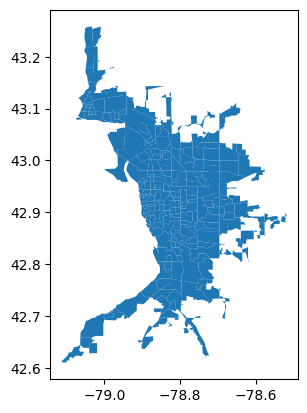

In [68]:
if not os.path.isdir("tracts_shapefile"):
    os.makedirs("tracts_shapefile")

# Cities that cross multiple state lines are seperated by multiple dashes
# e.g Seattle OR--WA
state = city_name.split(", ")[1]
census_tracts = gpd.GeoDataFrame()
for s in state.split("--"):
    # For each state in the city, extract the fips code (a two-digit number used to identify each US state and territory)
    fips_code = postal_to_fips[s]
    # Use string formatting to automatically download census tract shapefiles for each relevant state
    if not os.path.isdir(f"tracts_shapefile/{s}"):
        os.makedirs(f"tracts_shapefile/{s}")
        wget.download(f"https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_{fips_code}_tract_500k.zip", out=f"./tracts_shapefile/{s}")
    if census_tracts.empty:
        census_tracts = gpd.read_file(f"./tracts_shapefile/{s}/cb_2018_{fips_code}_tract_500k.zip")
    else:
        new_tracts = gpd.read_file(f"./tracts_shapefile/{s}/cb_2018_{fips_code}_tract_500k.zip")
        census_tracts = pd.concat([census_tracts, new_tracts])

# Extract the shapefile for the urban area from the earlier shapefile
city = gdf_cities[gdf_cities["NAME10"] == city_name]
# Get the intersection of the census tracts shapefile and the urban area shapefile
intersection = census_tracts.overlay(city, how="intersection")
f, ax = plt.subplots()
# Plot the intersection
intersection.plot(ax=ax)
os.makedirs(city_name, exist_ok=True)
os.makedirs(f"{city_name}/tracts", exist_ok=True)
intersection.to_file(f"{city_name}/tracts/city_with_tracts.shp")

In [ ]:
# TODO: This API interface has stopped working for some reaosn, try wget
products = ['tempo.l2.no2.vertical_column_troposphere', 'tempo.l2.hcho.vertical_column']
city = gdf_cities[gdf_cities["NAME10"] == city_name]
# Get the bounding box of the urban area
bbox = city.bounds

bbox = bbox.values[0]
# Use solar time to get midday results
# Every 15 degrees from the prime meridian is a one hour shift
#TODO: Run for 3 months (one season) with mid-day results
start_date = '2025-04-04'
end_date = '2025-04-05'

# Download the TEMPO data from the selected dates, over the selected area
# Need to use overwrite = true because the tempo api will re-use files with incomplete data
os.makedirs(f"{city_name}/TEMPO", exist_ok=True)
api = pyrsig.RsigApi(bdate=start_date, edate=end_date, bbox=bbox, overwrite = True, workdir=f"{city_name}/TEMPO")
tempokey = 'tempo.l2.no2.vertical_column_troposphere' # Formaldehyde, CO2, SO2
api_key = 'anonymous'  # using public data, so using anonymous TODO: Determine limits of public data
api.tempo_kw['api_key'] = api_key

# Convert to a data frame
for product in products:
    api.to_netcdf(product, removegz=True)

In [ ]:
# Convert the netcdf files to rdata
os.system(f"Rscript make_rdata.r \"{city_name}\"")

Loading required package: sp


[1] 1
[1] 1
Key: <longitude, latitude>
   longitude latitude longitude_bb latitude_bb          no2 local_time
       <num>    <num>       <list>      <list>        <num>      <int>
1: -79.11183 42.62376    <list[4]>   <list[4]> 3.186304e+14     124500
2: -79.11183 42.83377    <list[4]>   <list[4]> 4.967220e+15     172500
3: -79.11162 42.97377    <list[4]>   <list[4]> 5.224173e+15     202500
4: -79.11131 43.19258    <list[4]>   <list[4]> 7.762975e+15     124500
5: -79.11124 42.90693    <list[4]>   <list[4]> 6.446525e+15     124500
6: -79.11083 42.68060    <list[4]>   <list[4]> 1.066922e+15     162500
           hcho
          <num>
1: 8.323130e+15
2: 2.820928e+15
3: 6.151182e+15
4: 3.155451e+15
5: 6.015902e+15
6: 3.045010e+15


0

In [ ]:
# Fetch census data for the given city
os.system(f"Rscript census_data.r \"{city_name}\"")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Linking to GEOS 3.11.1, GDAL 3.6.4, PROJ 9.1.1; sf_use_s2() is TRUE
Loading required package: viridisLite
To install your API key for use in future sessions, run this function with `install = TRUE`.
Getting data from the 2019-2023 5-year ACS


Writing layer `demographics' to data source 
  `Buffalo, NY/demographics_shapefile/demographics.shp' using driver `ESRI Shapefile'
Writing 263 features with 20 fields and geometry type Multi Polygon.


There were 50 or more warnings (use warnings() to see the first 50)
Saving 7 x 7 in image
Saving 7 x 7 in image


0

In [ ]:
# Turn the pollution data into simple features objects
os.system(f"Rscript process_pollution_data.r \"{city_name}\"")

Linking to GEOS 3.11.1, GDAL 3.6.4, PROJ 9.1.1; sf_use_s2() is TRUE
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.4     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor() masks scales::col_factor()
✖ purrr::discard()    masks scales::discard()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: sp

Attaching package: ‘raster’

The following object is masked from ‘package:dplyr’:

    select

Loading required package: abind
Loading required package: viridisLite

Attaching package: ‘viridis’

The following object is masked from ‘package:scales’:

    viridis_pal



[1] "Buffalo, NY/RData/tempo.l2.no2.vertical_column_troposphere_2025-04-04T000000Z_2025-04-05T000000Z.RData"
  longitude latitude                               longitude_bb
1 -79.11183 42.62376 -79.07861, -79.08339, -79.14485, -79.14012
2 -79.11183 42.83377 -79.07850, -79.08331, -79.14503, -79.14024
3 -79.11162 42.97377 -79.07852, -79.08339, -79.14516, -79.14033
4 -79.11131 43.19258 -79.07690, -79.08185, -79.14441, -79.13950
5 -79.11124 42.90693 -79.07797, -79.08282, -79.14535, -79.14053
6 -79.11083 42.68060 -79.07737, -79.08217, -79.14380, -79.13904
                             latitude_bb          no2 local_time         hcho
1 42.63507, 42.61321, 42.61217, 42.63400 3.186304e+14     124500 8.323130e+15
2 42.84563, 42.82371, 42.82196, 42.84389 4.967220e+15     172500 2.820928e+15
3 42.98582, 42.96377, 42.96214, 42.98418 5.224173e+15     202500 6.151182e+15
4 43.20475, 43.18254, 43.18063, 43.20282 7.762975e+15     124500 3.155451e+15
5 42.91864, 42.89663, 42.89497, 42.91697 6.446525e+15

There were 50 or more warnings (use warnings() to see the first 50)
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image


0

In [ ]:
# Combine the pollution data and the demographic data 
os.system(f"Rscript combine_data.r \"{city_name}\"")

Linking to GEOS 3.11.1, GDAL 3.6.4, PROJ 9.1.1; sf_use_s2() is TRUE
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: sp

Attaching package: ‘raster’

The following object is masked from ‘package:dplyr’:

    select

Loading required package: viridisLite
Warning message:
attribute variables are assumed to be spatially constant throughout all geometries 
Saving 7 x 7 in image
Warning messages:
1: Removed 32 rows containing missing values or values outside the scale range
(`geom_point()`). 
2: Rem

0